In [1]:
%%capture

!pip install torch torch-geometric -f https://data.pyg.org/whl/torch-2.2.0+cpu.html
!pip install rdkit deepchem
!pip install pandas
!pip install tqdm tabulate

In [2]:
import pandas as pd
from rdkit import Chem
from torch_geometric.data import Data
import torch
from tqdm import tqdm
from tabulate import tabulate
import deepchem as dc

wandb: WARNING W&B installed but not logged in.  Run `wandb login` or set the WANDB_API_KEY env variable.
Instructions for updating:
experimental_relax_shapes is deprecated, use reduce_retracing instead
wandb: WARNING W&B installed but not logged in.  Run `wandb login` or set the WANDB_API_KEY env variable.


In [3]:
def load_dataset(path='cleanData.xlsx'):
    df = pd.read_excel(path)
    df = df.dropna(subset=['SMILES', 'single-class-label'])
    return df

dataset_df = load_dataset()
print(f"Loaded {len(dataset_df)} molecules.")

# transfer to list to make it compatible with featurizer
smiles_list = dataset_df['SMILES'].tolist()
labels = dataset_df['single-class-label'].tolist()

print("5 example of SMILES", smiles_list[:5])
print("Class of the 5 example smiles", labels[:5])

Loaded 4075 molecules.
5 example of SMILES ['CN(C)C(=O)Oc1cccc([N+](C)(C)C)c1', 'O=C(CCCCC1CCSS1)NCCCNc1c2c(nc3cc(Cl)ccc13)CCCC2', 'COc1cc2c(cc1OC)C(=O)C(CC1CCN(CCCNc3c4c(nc5cc(Cl)ccc35)CCCC4)CC1)C2', 'CNC(=O)Oc1cccc(CN(C)CCCOc2ccc3c(=O)c4ccccc4oc3c2)c1', 'CCC1=CC2Cc3nc4cc(Cl)ccc4c(N)c3[C@@H](C1)C2']
Class of the 5 example smiles [1, 1, 1, 1, 1]


In [4]:
# pair SMILES list to corresponding label
valid_data = []
invalid_smiles = []

for smiles, label in tqdm(zip(smiles_list, labels), total=len(smiles_list), desc="Validating and converting SMILES"):
    mol = Chem.MolFromSmiles(smiles)
    if mol is not None:
      valid_data.append((mol, smiles, label))
    else:
      invalid_smiles.append(smiles)

print("\n\nNumber of valid SMILES", len(valid_data))
print("5 example of valid data", valid_data[:5])
print("\nNumber of invalid SMILES:", len(invalid_smiles))
print("5 example of invalid SMILES", invalid_smiles[:5])

# Unzip list to tuple
mol, filtered_smiles_list, filtered_labels = zip(*valid_data)

print("\n5 examples of filtered_smiles_list tuple: ", filtered_smiles_list[:5])
print("corresponding label (in tuple): ", filtered_labels[:5])

Validating and converting SMILES: 100%|██████████| 4075/4075 [00:01<00:00, 3131.84it/s]



Number of valid SMILES 4075
5 example of valid data [(<rdkit.Chem.rdchem.Mol object at 0x7fc822c727a0>, 'CN(C)C(=O)Oc1cccc([N+](C)(C)C)c1', 1), (<rdkit.Chem.rdchem.Mol object at 0x7fc822c725e0>, 'O=C(CCCCC1CCSS1)NCCCNc1c2c(nc3cc(Cl)ccc13)CCCC2', 1), (<rdkit.Chem.rdchem.Mol object at 0x7fc822c72500>, 'COc1cc2c(cc1OC)C(=O)C(CC1CCN(CCCNc3c4c(nc5cc(Cl)ccc35)CCCC4)CC1)C2', 1), (<rdkit.Chem.rdchem.Mol object at 0x7fc822c72810>, 'CNC(=O)Oc1cccc(CN(C)CCCOc2ccc3c(=O)c4ccccc4oc3c2)c1', 1), (<rdkit.Chem.rdchem.Mol object at 0x7fc822c726c0>, 'CCC1=CC2Cc3nc4cc(Cl)ccc4c(N)c3[C@@H](C1)C2', 1)]

Number of invalid SMILES: 0
5 example of invalid SMILES []

5 examples of filtered_smiles_list tuple:  ('CN(C)C(=O)Oc1cccc([N+](C)(C)C)c1', 'O=C(CCCCC1CCSS1)NCCCNc1c2c(nc3cc(Cl)ccc13)CCCC2', 'COc1cc2c(cc1OC)C(=O)C(CC1CCN(CCCNc3c4c(nc5cc(Cl)ccc35)CCCC4)CC1)C2', 'CNC(=O)Oc1cccc(CN(C)CCCOc2ccc3c(=O)c4ccccc4oc3c2)c1', 'CCC1=CC2Cc3nc4cc(Cl)ccc4c(N)c3[C@@H](C1)C2')
corresponding label (in tuple):  (1, 1, 1, 1, 1)


╒════════════════════════════════════════════════════════════════════╤═════════╤═══════════════╤═══════════════╤═════════════╕
│ SMILES                                                             │   Label │ Formula       │   Mol. Weight │   Num Atoms │
╞════════════════════════════════════════════════════════════════════╪═════════╪═══════════════╪═══════════════╪═════════════╡
│ CN(C)C(=O)Oc1cccc([N+](C)(C)C)c1                                   │       1 │ C12H19N2O2+   │        223.3  │          16 │
├────────────────────────────────────────────────────────────────────┼─────────┼───────────────┼───────────────┼─────────────┤
│ O=C(CCCCC1CCSS1)NCCCNc1c2c(nc3cc(Cl)ccc13)CCCC2                    │       1 │ C24H32ClN3OS2 │        478.13 │          31 │
├────────────────────────────────────────────────────────────────────┼─────────┼───────────────┼───────────────┼─────────────┤
│ COc1cc2c(cc1OC)C(=O)C(CC1CCN(CCCNc3c4c(nc5cc(Cl)ccc35)CCCC4)CC1)C2 │       1 │ C33H40ClN3O3  │        562.15 

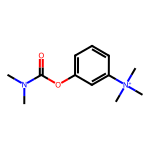

Molecule 2


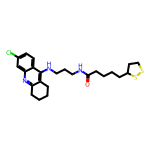

Molecule 3


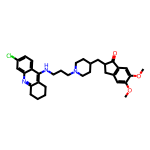

Molecule 4


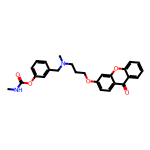

Molecule 5


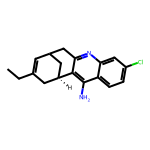

In [5]:
# Just to explain what is smiles

from rdkit.Chem import Descriptors, rdMolDescriptors, Draw
from tabulate import tabulate
from IPython.display import display
from PIL import Image
import io

valid_data_table = []
images = []

for mol_obj, smiles, label in valid_data[:5]:
    formula = rdMolDescriptors.CalcMolFormula(mol_obj)
    mw = Descriptors.MolWt(mol_obj)
    num_atoms = mol_obj.GetNumAtoms()

    # Create PIL image of molecule
    img = Draw.MolToImage(mol_obj, size=(150,150))
    images.append(img)

    # Add data row without the image (tabulate can’t embed images)
    valid_data_table.append([smiles, label, formula, f"{mw:.2f}", num_atoms])

# Print the table (without images)
print(tabulate(valid_data_table, headers=["SMILES", "Label", "Formula", "Mol. Weight", "Num Atoms"], tablefmt="fancy_grid"))

# Display images separately below the table with labels
print("\nMolecule drawings:")
for i, img in enumerate(images):
    print(f"Molecule {i+1}")
    display(img)

In [6]:
from sklearn.model_selection import train_test_split

# Split to train and test set by 80-20
smiles_train, smiles_temp, labels_train, labels_temp = train_test_split(
    filtered_smiles_list, filtered_labels, test_size=0.2, train_size=0.8, random_state=42, stratify=filtered_labels
)

# Further split test set to test-validation set to 10-10
smiles_test, smiles_val, labels_test, labels_val = train_test_split(
    smiles_temp, labels_temp, test_size=0.5, random_state=42, stratify=labels_temp
)

Memo: try without stratified later

In [7]:
def convmol_to_pyg(smiles_list, labels=None):
    featurizer = dc.feat.ConvMolFeaturizer()
    convmols = featurizer.featurize(smiles_list)

    data_list = []

    for idx, convmol in enumerate(convmols):
        if convmol is None:
            continue  # Skip failed molecules

        x = torch.tensor(convmol.get_atom_features(), dtype=torch.float)

        edge_list = []
        for start_idx, neighbors in enumerate(convmol.get_adjacency_list()):
            for end_idx in neighbors:
                edge_list.append((start_idx, end_idx))

        if len(edge_list) > 0:
            edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()
        else:
            edge_index = torch.empty((2, 0), dtype=torch.long)  # No bonds

        if labels is not None:
            y = torch.tensor([labels[idx]], dtype=torch.long)
            data = Data(x=x, edge_index=edge_index, y=y, smiles=smiles_list[idx])  # Store SMILES
        else:
            data = Data(x=x, edge_index=edge_index, smiles=smiles_list[idx])  # Store SMILES

        data_list.append(data)

    return data_list

In [8]:
train_graphs = convmol_to_pyg(smiles_train, labels_train)
val_graphs   = convmol_to_pyg(smiles_val, labels_val)
test_graphs  = convmol_to_pyg(smiles_test, labels_test)

Streaming output truncated to the last 5000 lines.
[06:02:51] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[06:02:51] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[06:02:51] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[06:02:51] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[06:02:51] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[06:02:51] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[06:02:51] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[06:02:51] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[06:02:51] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[06:02:51] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[06:02:51] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[06:02:51] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[06:02:51] DEPRECATION WARNING: please use GetValence(getExplicit=False)


In [9]:
data_list = convmol_to_pyg(smiles_list, labels)
data = data_list[0]  # first molecule
print("SMILES:", data.smiles)
print("Label:", data.y.item() if hasattr(data, "y") else "No label")
print("Atom features shape:", data.x.shape)
print("Atom features (first few rows):\n", data.x[:5])

Streaming output truncated to the last 5000 lines.
[06:03:01] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[06:03:01] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[06:03:01] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[06:03:01] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[06:03:01] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[06:03:01] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[06:03:01] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[06:03:01] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[06:03:01] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[06:03:01] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[06:03:01] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[06:03:01] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[06:03:01] DEPRECATION WARNING: please use GetValence(getExplicit=False)


SMILES: CN(C)C(=O)Oc1cccc([N+](C)(C)C)c1
Label: 1
Atom features shape: torch.Size([16, 75])
Atom features (first few rows):
 tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
         0., 1., 0.],
        [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
         0., 1., 0.],
        [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 

In [10]:
data = data_list[0]
print("SMILES:", data.smiles)
print("Label:", data.y.item() if hasattr(data, "y") else "No label")
print("Atom features shape:", data.x.shape)
print("Atom features (first few rows):\n", data.x[:5])

SMILES: CN(C)C(=O)Oc1cccc([N+](C)(C)C)c1
Label: 1
Atom features shape: torch.Size([16, 75])
Atom features (first few rows):
 tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
         0., 1., 0.],
        [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
         0., 1., 0.],
        [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 

# convert the ConvMol outputs into PyG Data objects

From ConvMolFeaturizer:

* nodes (numpy array): shape [num_atoms, num_features]

* edges (list of neighbor indices): adjacency list

Convert into:

* x = tensor(nodes)

* edge_index = tensor(edge list in COO format)

Train, test, val ratio: 80%, 10%, 10%

In [11]:
print(f"Train graphs: {len(train_graphs)}, Test graphs: {len(test_graphs)}, Validation graphs: {len(val_graphs)}")

# DataLoader
from torch_geometric.loader import DataLoader
train_loader = DataLoader(train_graphs, batch_size=32, shuffle=True)
test_loader = DataLoader(test_graphs, batch_size=32)
val_loader = DataLoader(val_graphs, batch_size=32)
print(f"Number of train set batches: {len(train_loader)}, Number of test set batches: {len(test_loader)}, Number of validation set batches: {len(val_loader)}")

Train graphs: 3260, Test graphs: 407, Validation graphs: 408
Number of train set batches: 102, Number of test set batches: 13, Number of validation set batches: 13


In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GraphConv, global_mean_pool

class DeepChemStyleGraphConv(nn.Module):
    def __init__(self,
                 node_feat_dim=75,
                 hidden_dims=[64, 64],
                 dense_dim=128,
                 dropout_rate=0.2,
                 n_classes=2,
                 batch_norm=True):
        super(DeepChemStyleGraphConv, self).__init__()

        self.convs = nn.ModuleList()
        self.bns = nn.ModuleList() if batch_norm else None

        # GraphConv layers
        in_channels = node_feat_dim
        for hidden_dim in hidden_dims:
            self.convs.append(GraphConv(in_channels, hidden_dim))
            if batch_norm:
                self.bns.append(nn.BatchNorm1d(hidden_dim))
            in_channels = hidden_dim

        # Dense layers after pooling
        self.fc1 = nn.Linear(in_channels, dense_dim)
        self.fc2 = nn.Linear(dense_dim, n_classes)

        self.dropout_rate = dropout_rate
        self.batch_norm = batch_norm

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        for i, conv in enumerate(self.convs):
            x = conv(x, edge_index)
            if self.batch_norm:
                x = self.bns[i](x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout_rate, training=self.training)

        # Global pooling
        x = global_mean_pool(x, batch)

        # Fully connected layers
        x = F.relu(self.fc1(x))
        x = F.dropout(x, p=self.dropout_rate, training=self.training)
        logits = self.fc2(x)

        return logits

In [13]:
import torch
import torch.nn.functional as F
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report
)
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os


def train_one_epoch(model, optimizer, criterion, loader, device):
    model.train()
    total_loss = 0
    for data in loader:
        data = data.to(device)
        optimizer.zero_grad()
        out = model(data)
        loss = criterion(out, data.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * data.num_graphs
    return total_loss / len(loader.dataset)


def evaluate_model(model, loader, device, is_binary=True, criterion=None):
    model.eval()
    all_preds, all_probs, all_labels = [], [], []
    total_loss = 0

    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            out = model(data)
            if criterion is not None:
                loss = criterion(out, data.y)
                total_loss += loss.item() * data.num_graphs

            probs = F.softmax(out, dim=1)
            preds = probs.argmax(dim=1)

            all_preds.append(preds.cpu())
            all_probs.append(probs.cpu()[:, 1] if is_binary else probs.cpu())
            all_labels.append(data.y.cpu())

    y_true = torch.cat(all_labels).numpy()
    y_pred = torch.cat(all_preds).numpy()
    y_prob = torch.cat(all_probs).numpy()

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='binary' if is_binary else 'macro')
    roc_auc = roc_auc_score(y_true, y_prob) if is_binary else roc_auc_score(y_true, y_prob, multi_class='ovr')

    cm = confusion_matrix(y_true, y_pred)
    report = classification_report(y_true, y_pred)

    val_loss = total_loss / len(loader.dataset) if criterion is not None else None

    return acc, f1, roc_auc, cm, report, val_loss


def plot_confusion_matrix(cm, class_names):
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.tight_layout()
    plt.show()

def plot_training_history(history):
    epochs = range(1, len(history['train_loss']) + 1)

    plt.figure(figsize=(15, 5))

    # Plot Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], label='Train Loss')
    plt.plot(epochs, history['val_loss'], label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Loss over Epochs')
    plt.legend()

    # Plot F1 / Accuracy / AUC
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['val_f1'], label='Val F1')
    plt.plot(epochs, history['val_acc'], label='Val Accuracy')
    plt.plot(epochs, history['val_auc'], label='Val AUC')
    plt.xlabel('Epoch')
    plt.ylabel('Score')
    plt.title('Validation Metrics over Epochs')
    plt.legend()

    plt.tight_layout()
    plt.show()

def run_training_loop(model, optimizer, criterion,
                      train_loader, val_loader, device,
                      num_epochs=30, save_path='best_model.pt',
                      is_binary=True, monitor_metric='f1',
                      csv_path='training_history.csv'):
    best_metric = -float('inf')
    history = {'train_loss': [], 'val_loss': [], 'val_f1': [], 'val_acc': [], 'val_auc': []}
    best_results = {}

    for epoch in range(1, num_epochs + 1):
        train_loss = train_one_epoch(model, optimizer, criterion, train_loader, device)
        acc, f1, roc_auc, cm, report, val_loss = evaluate_model(model, val_loader, device, is_binary, criterion)

        # Store history
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_f1'].append(f1)
        history['val_acc'].append(acc)
        history['val_auc'].append(roc_auc)

        print(f"[Epoch {epoch}] Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Acc: {acc:.4f} | F1: {f1:.4f} | AUC: {roc_auc:.4f}")

        # Save best model
        metric = {'f1': f1, 'auc': roc_auc, 'acc': acc}[monitor_metric]
        if metric > best_metric:
            best_metric = metric
            best_results = {'acc': acc, 'f1': f1, 'roc_auc': roc_auc, 'cm': cm, 'report': report}
            torch.save(model.state_dict(), save_path)
            print(f"✅ Saved new best model (epoch {epoch})")

    # Final results
    print("\n📊 Final Best Validation Metrics:")
    print(f"Accuracy: {best_results['acc']:.4f}")
    print(f"F1 Score: {best_results['f1']:.4f}")
    print(f"AUC-ROC: {best_results['roc_auc']:.4f}")
    print("\nClassification Report:\n", best_results['report'])
    plot_confusion_matrix(best_results['cm'], class_names=['0', '1'])

    # Plot curves
    plot_training_history(history)

    # Save to CSV
    df_history = pd.DataFrame(history)
    df_history.to_csv(csv_path, index_label='epoch')
    print(f"📁 Training history saved to {csv_path}")

    return history

[Epoch 1] Train Loss: 0.6233 | Val Loss: 0.5836 | Acc: 0.6593 | F1: 0.6293 | AUC: 0.7603
✅ Saved new best model (epoch 1)
[Epoch 2] Train Loss: 0.5735 | Val Loss: 0.5450 | Acc: 0.7402 | F1: 0.7056 | AUC: 0.8045
✅ Saved new best model (epoch 2)
[Epoch 3] Train Loss: 0.5516 | Val Loss: 0.5474 | Acc: 0.7157 | F1: 0.6398 | AUC: 0.7978
[Epoch 4] Train Loss: 0.5322 | Val Loss: 0.5293 | Acc: 0.7451 | F1: 0.6905 | AUC: 0.8168
[Epoch 5] Train Loss: 0.5150 | Val Loss: 0.5081 | Acc: 0.7549 | F1: 0.7126 | AUC: 0.8319
✅ Saved new best model (epoch 5)
[Epoch 6] Train Loss: 0.5118 | Val Loss: 0.4953 | Acc: 0.7672 | F1: 0.7493 | AUC: 0.8396
✅ Saved new best model (epoch 6)
[Epoch 7] Train Loss: 0.4916 | Val Loss: 0.4928 | Acc: 0.7721 | F1: 0.7365 | AUC: 0.8386
[Epoch 8] Train Loss: 0.4817 | Val Loss: 0.5100 | Acc: 0.7525 | F1: 0.6834 | AUC: 0.8575
[Epoch 9] Train Loss: 0.4749 | Val Loss: 0.4827 | Acc: 0.7574 | F1: 0.6954 | AUC: 0.8651
[Epoch 10] Train Loss: 0.4752 | Val Loss: 0.4684 | Acc: 0.7770 | F1

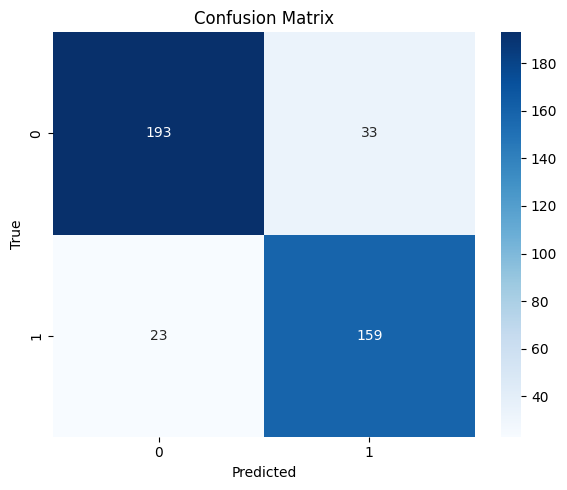

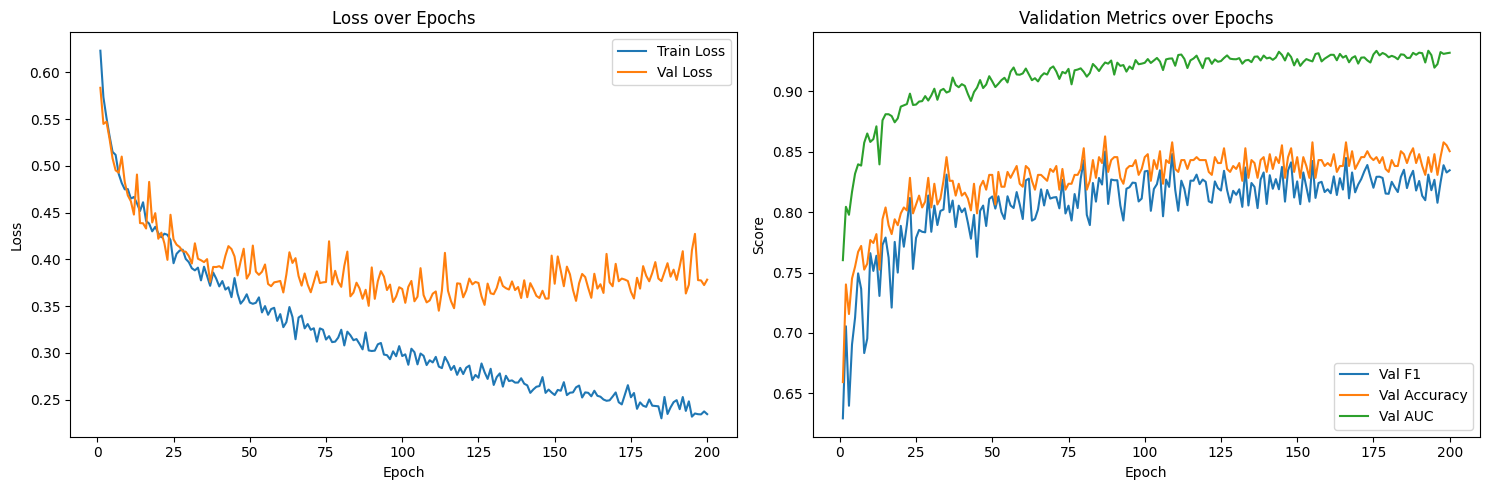

📁 Training history saved to training_history.csv


In [14]:
# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Instantiate model
model = DeepChemStyleGraphConv(node_feat_dim=75, n_classes=2).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Assume now we have:
# model, optimizer, criterion, train_loader, val_loader, device

history = run_training_loop(
    model=model,
    optimizer=optimizer,
    criterion=torch.nn.CrossEntropyLoss(),
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    num_epochs=200,
    save_path='best_model.pt',
    is_binary=True,
    monitor_metric='f1'  # could also be 'auc' or 'acc'
)

In [15]:
from torch_geometric.data import Data
import torch.nn as nn

class WrappedModel(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x, edge_index, batch):
        data = Data(x=x, edge_index=edge_index, batch=batch)
        out = self.model(data)
        return out  # must return raw logits


In [16]:
from torch_geometric.explain import Explainer, GNNExplainer

wrapped_model = WrappedModel(model).to(device)

explainer = Explainer(
    model=wrapped_model,
    algorithm=GNNExplainer(epochs=200),
    explanation_type='model',
    node_mask_type='attributes',
    edge_mask_type='object',
    model_config=dict(
        mode='binary_classification',  # or 'multiclass_classification'
        task_level='graph',
        return_type='raw',
    )
)


In [17]:
from torch_geometric.loader import DataLoader

# Get a single graph from val_loader (not a batch!)
val_graph = val_graphs[0]  # or pick a specific graph index
val_graph = val_graph.to(device)
print(f"SMILES string for the explained molecule: {val_graph.smiles}")

SMILES string for the explained molecule: COc1cccc(CN2CCC(/C=C3\Cc4cccc(OC)c4C3=O)CC2)c1


In [18]:
explanation = explainer(
    x=val_graph.x,
    edge_index=val_graph.edge_index,
    batch=torch.zeros(val_graph.x.size(0), dtype=torch.long).to(device)  # single graph → batch of 0s
)

In [19]:
print(explanation)

Explanation(node_mask=[28, 75], edge_mask=[62], prediction=[1, 2], target=[2], x=[28, 75], edge_index=[2, 62], batch=[28])


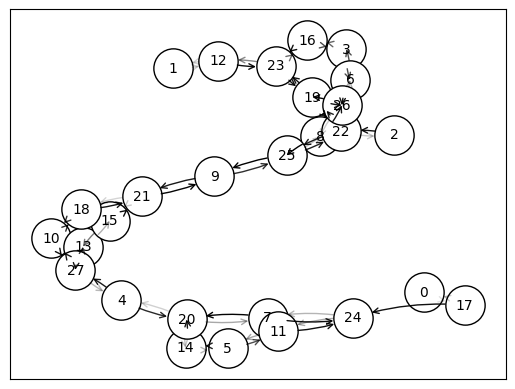

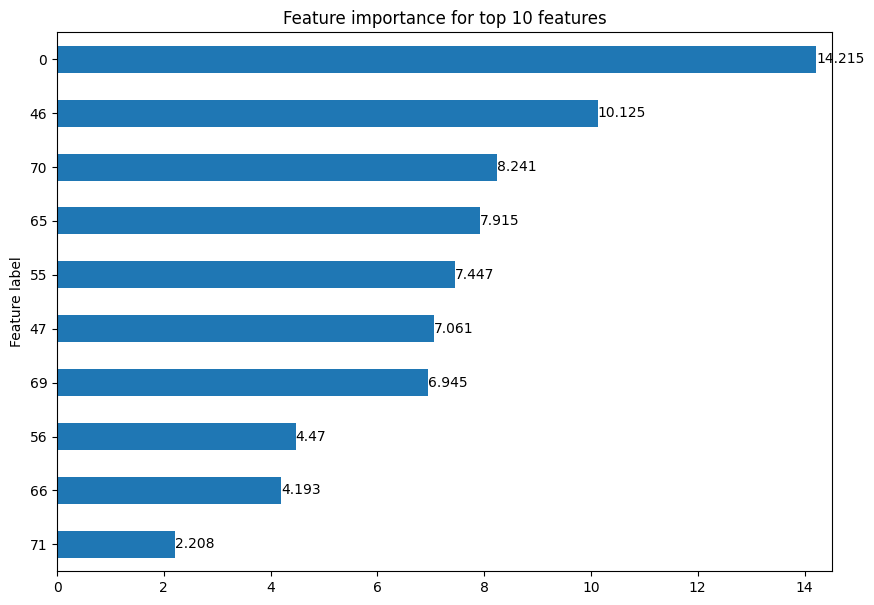

In [20]:
# Generate explanation
explanation = explainer(
    x=val_graph.x,
    edge_index=val_graph.edge_index,
    batch=torch.zeros(val_graph.x.size(0), dtype=torch.long).to(device)
)

# Visualize graph with edge importance
explanation.visualize_graph(backend='networkx')

# Visualize top-10 most important input features
explanation.visualize_feature_importance(top_k=10)

In [21]:
from deepchem.feat import ConvMolFeaturizer
from rdkit import Chem

# Example molecule
mol = Chem.MolFromSmiles("COc1cccc(CN2CCC(/C=C3\\Cc4cccc(OC)c4C3=O)CC2)c1")
featurizer = ConvMolFeaturizer()
mol_graph = featurizer.featurize([mol])[0]

# Look at atom 0's feature vector
atom_feat_vector = mol_graph.get_atom_features()[0]

# Print feature vector with index
for idx, val in enumerate(atom_feat_vector):
    print(f"Feature {idx}: {val}")

Feature 0: 1.0
Feature 1: 0.0
Feature 2: 0.0
Feature 3: 0.0
Feature 4: 0.0
Feature 5: 0.0
Feature 6: 0.0
Feature 7: 0.0
Feature 8: 0.0
Feature 9: 0.0
Feature 10: 0.0
Feature 11: 0.0
Feature 12: 0.0
Feature 13: 0.0
Feature 14: 0.0
Feature 15: 0.0
Feature 16: 0.0
Feature 17: 0.0
Feature 18: 0.0
Feature 19: 0.0
Feature 20: 0.0
Feature 21: 0.0
Feature 22: 0.0
Feature 23: 0.0
Feature 24: 0.0
Feature 25: 0.0
Feature 26: 0.0
Feature 27: 0.0
Feature 28: 0.0
Feature 29: 0.0
Feature 30: 0.0
Feature 31: 0.0
Feature 32: 0.0
Feature 33: 0.0
Feature 34: 0.0
Feature 35: 0.0
Feature 36: 0.0
Feature 37: 0.0
Feature 38: 0.0
Feature 39: 0.0
Feature 40: 0.0
Feature 41: 0.0
Feature 42: 0.0
Feature 43: 0.0
Feature 44: 0.0
Feature 45: 1.0
Feature 46: 0.0
Feature 47: 0.0
Feature 48: 0.0
Feature 49: 0.0
Feature 50: 0.0
Feature 51: 0.0
Feature 52: 0.0
Feature 53: 0.0
Feature 54: 0.0
Feature 55: 0.0
Feature 56: 0.0
Feature 57: 0.0
Feature 58: 1.0
Feature 59: 0.0
Feature 60: 0.0
Feature 61: 0.0
Feature 62: 0.0
Fe

[06:05:15] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[06:05:15] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[06:05:15] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[06:05:15] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[06:05:15] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[06:05:15] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[06:05:15] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[06:05:15] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[06:05:15] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[06:05:15] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[06:05:15] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[06:05:15] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[06:05:15] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[06:05:15] DEPRECATION WARNING: please use GetValen

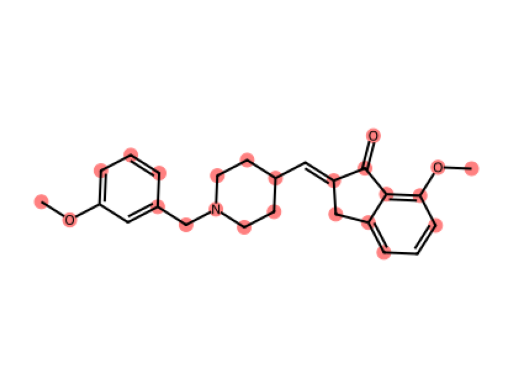

In [22]:
import matplotlib.pyplot as plt
from rdkit.Chem import Draw

# Get list of atoms where feature 0 = 1
hydrogen_atoms = [i for i, row in enumerate(val_graph.x) if row[0] == 1]

# Draw molecule with highlight
rdkit_mol = Chem.MolFromSmiles("COc1cccc(CN2CCC(/C=C3\\Cc4cccc(OC)c4C3=O)CC2)c1")
img = Draw.MolToImage(rdkit_mol, highlightAtoms=hydrogen_atoms, size=(400, 300))
plt.imshow(img)
plt.axis('off')
plt.show()


In [23]:
explanation.visualize_graph(path='explained_graph.png')
explanation.visualize_feature_importance(path='feature_importance.png', top_k=10)

In [24]:
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import rdMolDraw2D
import numpy as np

def visualize_explained_molecule(explanation, smiles: str, edge_threshold=0.1):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError("Invalid SMILES:", smiles)

    edge_index = explanation.edge_index.cpu().numpy()
    edge_mask = explanation.edge_mask.cpu().detach().numpy()

    # Normalize edge mask
    edge_mask = (edge_mask - edge_mask.min()) / (edge_mask.max() - edge_mask.min() + 1e-10)

    # RDKit uses bond indices, not edge_index, so we must map PyG edges to RDKit bonds
    bond_weights = {}
    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()

        # Find corresponding index in edge_index
        for idx, (u, v) in enumerate(edge_index.T):  # shape [2, num_edges]
            if (u == i and v == j) or (u == j and v == i):
                bond_weights[bond.GetIdx()] = edge_mask[idx]
                break

    # Highlighting setup
    highlight_bonds = [k for k, v in bond_weights.items() if v > edge_threshold]
    bond_colors = {k: (1 - v, v, 0.0) for k, v in bond_weights.items()}  # RGB: green-red

    drawer = rdMolDraw2D.MolDraw2DCairo(400, 400)
    drawer.DrawMolecule(
        mol,
        highlightBonds=highlight_bonds,
        highlightBondColors=bond_colors
    )
    drawer.FinishDrawing()

    png = drawer.GetDrawingText()
    from PIL import Image
    import io
    return Image.open(io.BytesIO(png))

# explain a single graph

In [25]:
# Assume val_graphs is your list of Data objects (with smiles)
val_graph = val_graphs[0]
val_graph = val_graph.to(device)

# Create dummy batch vector for single graph
batch = torch.zeros(val_graph.num_nodes, dtype=torch.long).to(device)

# Run explainer
explanation = explainer(
    x=val_graph.x,
    edge_index=val_graph.edge_index,
    batch=batch
)

In [26]:
print(f"SMILES string for the explained molecule: {val_graph.smiles}")

SMILES string for the explained molecule: COc1cccc(CN2CCC(/C=C3\Cc4cccc(OC)c4C3=O)CC2)c1


## visualize

In [27]:
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import rdMolDraw2D
from rdkit.Chem.Draw.rdMolDraw2D import MolDraw2DCairo
import numpy as np
from PIL import Image
import io

def visualize_explained_molecule_with_nodes_and_edges(explanation, smiles: str, edge_threshold=0.1, node_threshold=0.1):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError("Invalid SMILES:", smiles)

    # ---- Edge mask handling ----
    edge_index = explanation.edge_index.cpu().numpy()
    edge_mask = explanation.edge_mask.cpu().detach().numpy()

    # Normalize edge mask
    edge_mask = (edge_mask - edge_mask.min()) / (edge_mask.max() - edge_mask.min() + 1e-10)

    # Map to RDKit bond indices
    bond_weights = {}
    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        scores = [
            float(edge_mask[idx]) for idx, (u, v) in enumerate(edge_index.T)
            if (u == i and v == j) or (u == j and v == i)
        ]
        if scores:
            bond_weights[bond.GetIdx()] = np.mean(scores)

    highlight_bonds = [k for k, v in bond_weights.items() if v > edge_threshold]
    bond_colors = {k: (float(1 - v), float(v), 0.0) for k, v in bond_weights.items()}

    # ---- Node mask handling ----
    if hasattr(explanation, 'node_mask') and explanation.node_mask is not None:
        node_mask = explanation.node_mask.cpu().detach().numpy()

        if len(node_mask.shape) == 2:  # [num_nodes, num_features]
            node_mask = node_mask.sum(axis=1)

        # Normalize
        node_mask = (node_mask - node_mask.min()) / (node_mask.max() - node_mask.min() + 1e-10)

        highlight_atoms = [i for i, v in enumerate(node_mask) if v > node_threshold]
        atom_colors = {i: (float(1 - v), float(v), 0.0) for i, v in enumerate(node_mask) if v > node_threshold}
    else:
        highlight_atoms = []
        atom_colors = {}

    # ---- Draw the molecule ----
    drawer = MolDraw2DCairo(400, 400)
    drawer.DrawMolecule(
        mol,
        highlightAtoms=highlight_atoms,
        highlightAtomColors=atom_colors,
        highlightBonds=highlight_bonds,
        highlightBondColors=bond_colors
    )
    drawer.FinishDrawing()

    png = drawer.GetDrawingText()
    return Image.open(io.BytesIO(png))

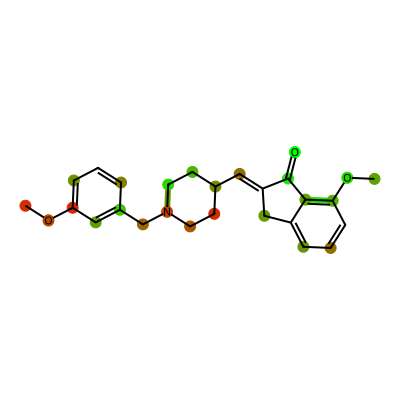

In [28]:
img = visualize_explained_molecule_with_nodes_and_edges(
    explanation,
    smiles=val_graph.smiles,
    edge_threshold=0.1,
    node_threshold=0.1
)
display(img)

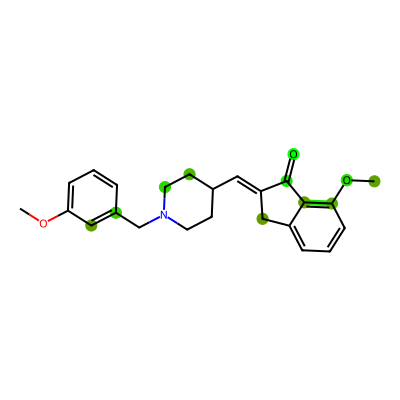

In [29]:
img = visualize_explained_molecule_with_nodes_and_edges(
    explanation,
    smiles=val_graph.smiles,
    edge_threshold=0.6,
    node_threshold=0.6
)
display(img)

## explain using sentence (also cross-checking)

In [30]:
def extract_explanation_sentence(explanation, mol, class_names=["Negative", "Positive"],
                                 node_threshold=0.1, edge_threshold=0.1, top_k=3):
    atom_names = [atom.GetSymbol() for atom in mol.GetAtoms()]
    sentences = []

    # --- Node mask (atom importance) ---
    node_mask = explanation.node_mask
    if node_mask is not None:
        node_mask = node_mask.cpu().detach().numpy()
        if node_mask.ndim == 2:
            node_mask = node_mask.sum(axis=1)
        node_mask = (node_mask - node_mask.min()) / (node_mask.max() - node_mask.min() + 1e-10)

        important_atoms = [(i, float(score)) for i, score in enumerate(node_mask) if score > node_threshold]
        important_atoms = sorted(important_atoms, key=lambda x: x[1], reverse=True)
        if important_atoms:
            atom_desc = ", ".join(
                [f"{atom_names[i]} (index {i}, score {score:.2f})" for i, score in important_atoms[:top_k]]
            )
            sentences.append(f"The model focused on the following atoms: {atom_desc}.")

    # --- Edge mask (bond importance) with bidirectional averaging ---
    edge_mask = explanation.edge_mask
    if edge_mask is not None:
        edge_mask = edge_mask.cpu().detach().numpy()
        edge_mask = (edge_mask - edge_mask.min()) / (edge_mask.max() - edge_mask.min() + 1e-10)
        edge_index = explanation.edge_index.cpu().numpy()

        bond_weights = {}
        for bond in mol.GetBonds():
            i = bond.GetBeginAtomIdx()
            j = bond.GetEndAtomIdx()
            scores = [
                float(edge_mask[idx]) for idx, (u, v) in enumerate(edge_index.T)
                if (u == i and v == j) or (u == j and v == i)
            ]
            if scores:
                bond_weights[(i, j)] = np.mean(scores)

        important_bonds = [(i, j, score) for (i, j), score in bond_weights.items() if score > edge_threshold]
        important_bonds = sorted(important_bonds, key=lambda x: x[2], reverse=True)
        if important_bonds:
            bond_desc = ", ".join(
                [f"{atom_names[i]}-{atom_names[j]} (indices {i}-{j}, score {score:.2f})"
                 for i, j, score in important_bonds[:top_k]]
            )
            sentences.append(f"The most influential bonds include: {bond_desc}.")

    # --- Classification result ---
    pred_label = None
    if hasattr(explanation, "y") and explanation.y is not None:
        try:
            pred_label = int(explanation.y.item())
        except Exception as e:
            print(f"Warning: explanation.y exists but could not be interpreted: {e}")

    if pred_label is None and hasattr(explanation, "prediction") and explanation.prediction is not None:
        try:
            pred_label = int(explanation.prediction.argmax().item())
        except Exception as e:
            print(f"Warning: explanation.prediction fallback also failed: {e}")

    if pred_label is not None:
        class_str = class_names[pred_label] if pred_label < len(class_names) else str(pred_label)
        sentences.append(f"The model predicted this molecule as **{class_str}**.")

    if not sentences:
        return "No explanation information could be extracted."

    return " ".join(sentences)


In [31]:
from rdkit import Chem

mol = Chem.MolFromSmiles(val_graph.smiles)
sentence = extract_explanation_sentence(
    explanation,
    mol,
    class_names=["Non-ACHE", "ACHE Inhibitor"]
)
print(sentence)

The model focused on the following atoms: O (index 24, score 1.00), C (index 23, score 0.93), O (index 20, score 0.85). The most influential bonds include: C-C (indices 19-22, score 0.89), C-N (indices 26-8, score 0.59). The model predicted this molecule as **ACHE Inhibitor**.


## with index visible

In [32]:
from rdkit import Chem
from rdkit.Chem.Draw import rdMolDraw2D
from rdkit.Chem import Draw
from IPython.display import Image as IPyImage
import io
import numpy as np

def visualize_and_explain_molecule_with_indices(model, data, explanation,
                                                class_names=["Class 0", "Class 1"],
                                                node_threshold=0.1,
                                                edge_threshold=0.1,
                                                return_sentence=True,
                                                image_size=(700, 700)):
    smiles = data.smiles
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError("Invalid SMILES string.")

    atom_names = [atom.GetSymbol() for atom in mol.GetAtoms()]

    # --- Node mask ---
    node_mask = explanation.node_mask
    if node_mask is not None:
        node_mask = node_mask.cpu().detach().numpy()
        if node_mask.ndim == 2:
            node_mask = node_mask.sum(axis=1)
        node_mask = (node_mask - node_mask.min()) / (node_mask.max() - node_mask.min() + 1e-10)
        highlight_atoms = [i for i, score in enumerate(node_mask) if score > node_threshold]
        atom_colors = {i: (1 - float(score), float(score), 0.0) for i, score in enumerate(node_mask)}
    else:
        highlight_atoms = []
        atom_colors = {}

    # --- Edge mask ---
    edge_index = explanation.edge_index.cpu().numpy()
    edge_mask = explanation.edge_mask.cpu().detach().numpy()
    edge_mask = (edge_mask - edge_mask.min()) / (edge_mask.max() - edge_mask.min() + 1e-10)

    bond_weights = {}
    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()

        scores = [float(edge_mask[idx]) for idx, (u, v) in enumerate(edge_index.T)
                  if (u == i and v == j) or (u == j and v == i)]

        if scores:
            bond_weights[bond.GetIdx()] = np.mean(scores)

    highlight_bonds = [k for k, v in bond_weights.items() if v > edge_threshold]
    bond_colors = {k: (1 - float(v), float(v), 0.0) for k, v in bond_weights.items()}

    # --- Draw molecule ---
    width, height = image_size
    drawer = rdMolDraw2D.MolDraw2DCairo(width, height)
    drawer.drawOptions().addAtomIndices = True
    drawer.drawOptions().fixedScale = 1.5
    drawer.drawOptions().padding = 0.1
    drawer.drawOptions().highlightBondWidthMultiplier = 16  # thicker highlights

    drawer.DrawMolecule(mol,
                        highlightAtoms=highlight_atoms,
                        highlightAtomColors=atom_colors,
                        highlightBonds=highlight_bonds,
                        highlightBondColors=bond_colors)
    drawer.FinishDrawing()

    img_bytes = drawer.GetDrawingText()
    img = IPyImage(data=img_bytes)

    # --- Generate explanation sentence ---
    sentences = []

    if highlight_atoms:
        top_atoms = sorted([(i, node_mask[i]) for i in highlight_atoms], key=lambda x: -x[1])
        atom_desc = ", ".join([f"{atom_names[i]} (index {i}, score {score:.2f})" for i, score in top_atoms[:3]])
        sentences.append(f"The model focused on the following atoms: {atom_desc}.")

    if bond_weights:
        top_bonds = sorted(bond_weights.items(), key=lambda x: -x[1])
        top_bond_desc = []
        for bond_idx, score in top_bonds[:3]:
            bond = mol.GetBondWithIdx(bond_idx)
            i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
            bond_str = f"{atom_names[i]}-{atom_names[j]} (indices {i}-{j}, score {score:.2f})"
            top_bond_desc.append(bond_str)
        if top_bond_desc:
            sentences.append(f"The most influential bonds include: {', '.join(top_bond_desc)}.")

    if hasattr(explanation, "y") and explanation.y is not None:
        try:
            pred_label = int(explanation.y.item())
            class_str = class_names[pred_label] if pred_label < len(class_names) else str(pred_label)
            sentences.append(f"The model predicted this molecule as **{class_str}**.")
        except Exception as e:
            sentences.append("Prediction could not be parsed.")

    sentence_output = " ".join(sentences)

    if return_sentence:
        return img, sentence_output
    else:
        return img


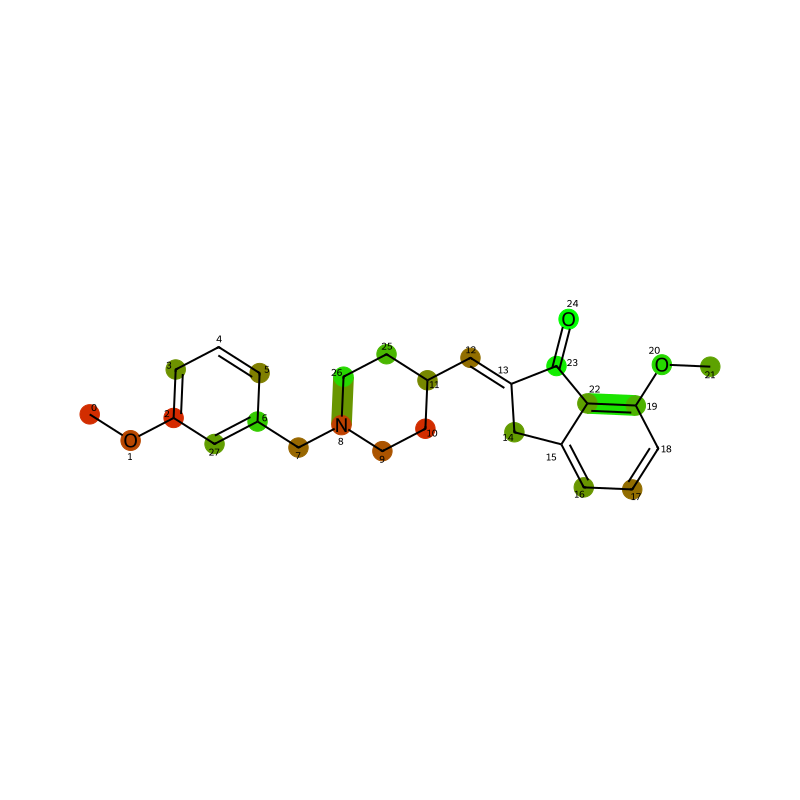

The model focused on the following atoms: O (index 24, score 1.00), C (index 23, score 0.93), O (index 20, score 0.85). The most influential bonds include: C-C (indices 19-22, score 0.89), C-N (indices 26-8, score 0.59).


In [33]:
fig, sentence = visualize_and_explain_molecule_with_indices(
    model, val_graph, explanation,
    class_names=["Non-ACHE", "ACHE Inhibitor"],
    return_sentence=True,
    image_size=(800, 800)
)

display(fig)
print(sentence)
